In [4]:
import os
import sys
sys.path.append(os.path.expanduser('~'))
import numpy as np 
from matplotlib import pyplot as plt
from datetime import datetime as dt
import figures as fgs
from albatros_analysis.src.correlations import baseband_data_classes as bdc
from albatros_analysis.src.utils import baseband_utils as butils
from albatros_analysis.src.utils import orbcomm_utils as outils
import time
import importlib
import json
from scipy.optimize import minimize
from skyfield.api import load, wgs84
import fitting_helper as fh
import argparse
import numpy as np 
from matplotlib import pyplot as plt
from datetime import datetime as dt
from albatros_analysis.src.correlations import baseband_data_classes as bdc
from albatros_analysis.src.utils import baseband_utils as butils
from albatros_analysis.src.utils import orbcomm_utils as outils
import numba as nb
import time
import importlib
from scipy.ndimage import median_filter 
import json
from scipy.optimize import minimize,check_grad,least_squares
sys.path.append(os.path.expanduser('~'))

In [5]:
@nb.njit(parallel=True)
def apply_delay(arr, out, delay, freqs):
    # apply delay to an array of complex electric field or their correlation
    # does exp( j 2 pi nu tau) sign of tau is user dependent
    # freqs should correspond to the columns of the nspec x nchan array
    nspec = arr.shape[0]
    nchan = arr.shape[1]
    for i in nb.prange(nspec):
        for j in range(nchan):
            out[i, j] = arr[i, j] * np.exp(2j * np.pi * freqs[j] * delay[i])
    return out

@nb.njit(parallel=True)
def xcorr_avg(arr1,arr2,acclen):
    #helper function
    nblocks = arr1.shape[0]//acclen
    nchan = arr1.shape[1]
    out = np.zeros((nblocks,nchan),dtype=arr1.dtype)
    for i in nb.prange(nblocks):
        for j in range(acclen):
            for k in range(nchan):
                out[i,k] += arr1[i*acclen + j,k]*np.conj(arr2[i*acclen + j,k])
        out[i,:]/=acclen
    return out

In [52]:
path_config = "/home/thomasb/albatros_analysis/scripts/orbcomm/config/config_batch2.json"

with open(path_config, "r") as f:
    config = json.load(f)
antpos=[]
for i, (ant, details) in enumerate(config["antennas"].items()):
        antpos.append(details["coordinates"])
print(antpos)

batch_start_ts = config["correlation"]["start_timestamp"]
batch_end_ts = config["correlation"]["end_timestamp"]
osamp = config['correlation']['osamp']
acclen = config['correlation']['new_acclen']

T_SPECTRA = 4096/250e6 * osamp
print(T_SPECTRA)

[[79.41717895, -90.76721818, 188.095], [79.41721848, -90.75872502, 183.51076468], [79.38845797, -91.01936185, 19.777], [79.4183154, -90.667425, 59.364], [79.3979952, -90.799868, 42.692], [79.41148497, -90.69528512, 32.593], [79.44377162, -90.71824306, 416.829]]
0.001048576


In [53]:
path_batch = f'/scratch/thomasb/full_timing_discrepancies_{batch_start_ts}'

fname_pulses = "pulses2.json"
path_pulses = os.path.join(path_batch, fname_pulses)
fname_cutter = "cutting.json"
path_cutter = os.path.join(path_batch, fname_cutter)
fname_map = 'times_all_incoherent.json'
path_map = os.path.join(path_batch, fname_map)

In [54]:
with open(path_pulses, "r") as f_pulses:
        pulse_list = json.load(f_pulses)
with open(path_cutter, "r") as f_cutter:
        cutter_dict = json.load(f_cutter)
with open(path_map, "r") as f_map:
        map_dict = json.load(f_map)

In [69]:
idx_pulse = 2

#extract from pulses json
pulse = pulse_list[idx_pulse]
print(pulse)

pulse_start_ts = pulse['t_start']
pulse_end_ts = pulse['t_end']
satID = pulse['sat']
chan_det = pulse['channel']
print('detection channel', chan_det)

ant_idxs = [0, 2, 3, 4, 5, 6]
ant_nums = [1, 2, 4, 5, 6, 7, 8]

if chan_det%2 == 0:
    chans_old = np.arange(chan_det-2, chan_det+2) + 1834
else:
    chans_old = np.arange(chan_det-1, chan_det+3) + 1834

print(chans_old)

{'antenna': 'Antenna 2', 'sat': 57166, 'channel': 3, 't_start': 1753204614, 't_end': 1753204859, 'len': 245}
detection channel 3
[1836 1837 1838 1839]


In [70]:
fname_data = f"data_raw_osamp=64_start={pulse_start_ts}_end={pulse_end_ts}_chans={chans_old[0]}:{chans_old[-1]}.npy"

In [86]:
#extract from cutter json
cut = cutter_dict[fname_data]

chan_new_start, chan_new_end  = cut["new_chans"]
chans_new = np.arange(chan_new_start, chan_new_end)
print(chans_new)

spectra_cut_start = cut["spectra_start"]
time_cut_start = spectra_cut_start * T_SPECTRA
spectra_cut_end = cut["spectra_end"]
time_cut_end = spectra_cut_end * T_SPECTRA

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79]


In [95]:
data = np.load(os.path.join(path_batch, fname_data))
data = data[:, :, :, chans_new]
print(data.shape)

(7, 2, 233472, 80)


In [96]:
#extract from mapping json
map = map_dict[fname_data]

pulse_start_spec = map["start_spectrum"]
print('starting specnum', pulse_start_spec)

m = 1.638400946109685e-05
c = 1753200128.469018

pulse_start_fitted = m*pulse_start_spec + c
print(pulse_start_fitted)

starting specnum 273770916
1753204613.934296


In [97]:
tle_path = outils.get_tle_file(pulse_start_fitted, "/project/rrg-sievers/mohanagr/OCOMM_TLES")

freqs = (chans_new/64 + chans_old[0])*250e6/4096
freqs = 250e6-freqs

print(freqs)
print(freqs.shape)

[1.37939453e+08 1.37938499e+08 1.37937546e+08 1.37936592e+08
 1.37935638e+08 1.37934685e+08 1.37933731e+08 1.37932777e+08
 1.37931824e+08 1.37930870e+08 1.37929916e+08 1.37928963e+08
 1.37928009e+08 1.37927055e+08 1.37926102e+08 1.37925148e+08
 1.37924194e+08 1.37923241e+08 1.37922287e+08 1.37921333e+08
 1.37920380e+08 1.37919426e+08 1.37918472e+08 1.37917519e+08
 1.37916565e+08 1.37915611e+08 1.37914658e+08 1.37913704e+08
 1.37912750e+08 1.37911797e+08 1.37910843e+08 1.37909889e+08
 1.37908936e+08 1.37907982e+08 1.37907028e+08 1.37906075e+08
 1.37905121e+08 1.37904167e+08 1.37903214e+08 1.37902260e+08
 1.37901306e+08 1.37900352e+08 1.37899399e+08 1.37898445e+08
 1.37897491e+08 1.37896538e+08 1.37895584e+08 1.37894630e+08
 1.37893677e+08 1.37892723e+08 1.37891769e+08 1.37890816e+08
 1.37889862e+08 1.37888908e+08 1.37887955e+08 1.37887001e+08
 1.37886047e+08 1.37885094e+08 1.37884140e+08 1.37883186e+08
 1.37882233e+08 1.37881279e+08 1.37880325e+08 1.37879372e+08
 1.37878418e+08 1.378774

In [98]:
# chanids=np.arange(80)
# chan = 4096*64-(1834*64+chanids)
# freq = chan*250e6/4096/64
# print(len(freq))

In [99]:
n_blines = len(ant_idxs)*(len(ant_idxs)-1)//2

multi_vis = np.zeros((n_blines, data.shape[2]//acclen, data.shape[3]), dtype='complex64', order='c')
print("multi_vis shape", multi_vis.shape)

bl_proc=0

for i in range(len(ant_idxs)):
        for j in range(i+1, len(ant_idxs)):
            ai = ant_idxs[i]
            aj = ant_idxs[j]
            a1_coords=antpos[ai]
            a2_coords=antpos[aj]
            dly = outils.get_sat_delay(
                                a1_coords,
                                a2_coords,
                                tle_path,
                                pulse_start_fitted,
                                int(pulse_end_ts - pulse_start_ts)+2,  #BEWARE maybe the fitting messed this up
                                satID,
                                altaz=False
                            )
            delay = np.interp(
                np.arange(0, data.shape[2]) * T_SPECTRA, np.arange(0, int(pulse_end_ts - pulse_start_ts)+2), dly
            )
            spec1=data[ai,0,:,:]
            spec2=data[aj,0,:,:]
            spec2_phased = np.empty_like(spec2)
            # print("spec2", spec2_phased.shape)
            # print(spec2_phased.flags)
            spec2_phased = apply_delay(spec2, spec2_phased, -delay, freqs)
            Vxx = xcorr_avg(spec1,spec2_phased,acclen)
            spec1=data[ai,1,:,:]
            spec2=data[aj,1,:,:]
            spec2_phased = np.empty_like(spec2)
            spec2_phased = apply_delay(spec2, spec2_phased, -delay, freqs)
            Vyy = xcorr_avg(spec1,spec2_phased,acclen)
            multi_vis[bl_proc,:,:] = (Vxx+Vyy)/2
            bl_proc+=1
            print("done", ai,aj,".Processed",bl_proc, "baselines")

multi_vis shape (15, 228, 80)
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.13339972496032715
done 0 2 .Processed 1 baselines
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.1749565601348877
done 0 3 .Processed 2 baselines
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.13065505027770996


done 0 4 .Processed 3 baselines
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.1308274269104004
done 0 5 .Processed 4 baselines
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.13002586364746094
done 0 6 .Processed 5 baselines
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.1262798309326172
done 2 3 .Processed 6 baselines
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.13118267059326172
done 2 4 .Processed 7 baselines
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.12585020065307617
done 2 5 .Processed 8 baselines
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.1253983974456787
done 2 6 .Processed 9 baselines
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.15183210372924805
done 3 4 .Processed 10 baselines
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.12575101852416992
done 3 5 .Processed 11 baselines
catalog #57166 ep

15


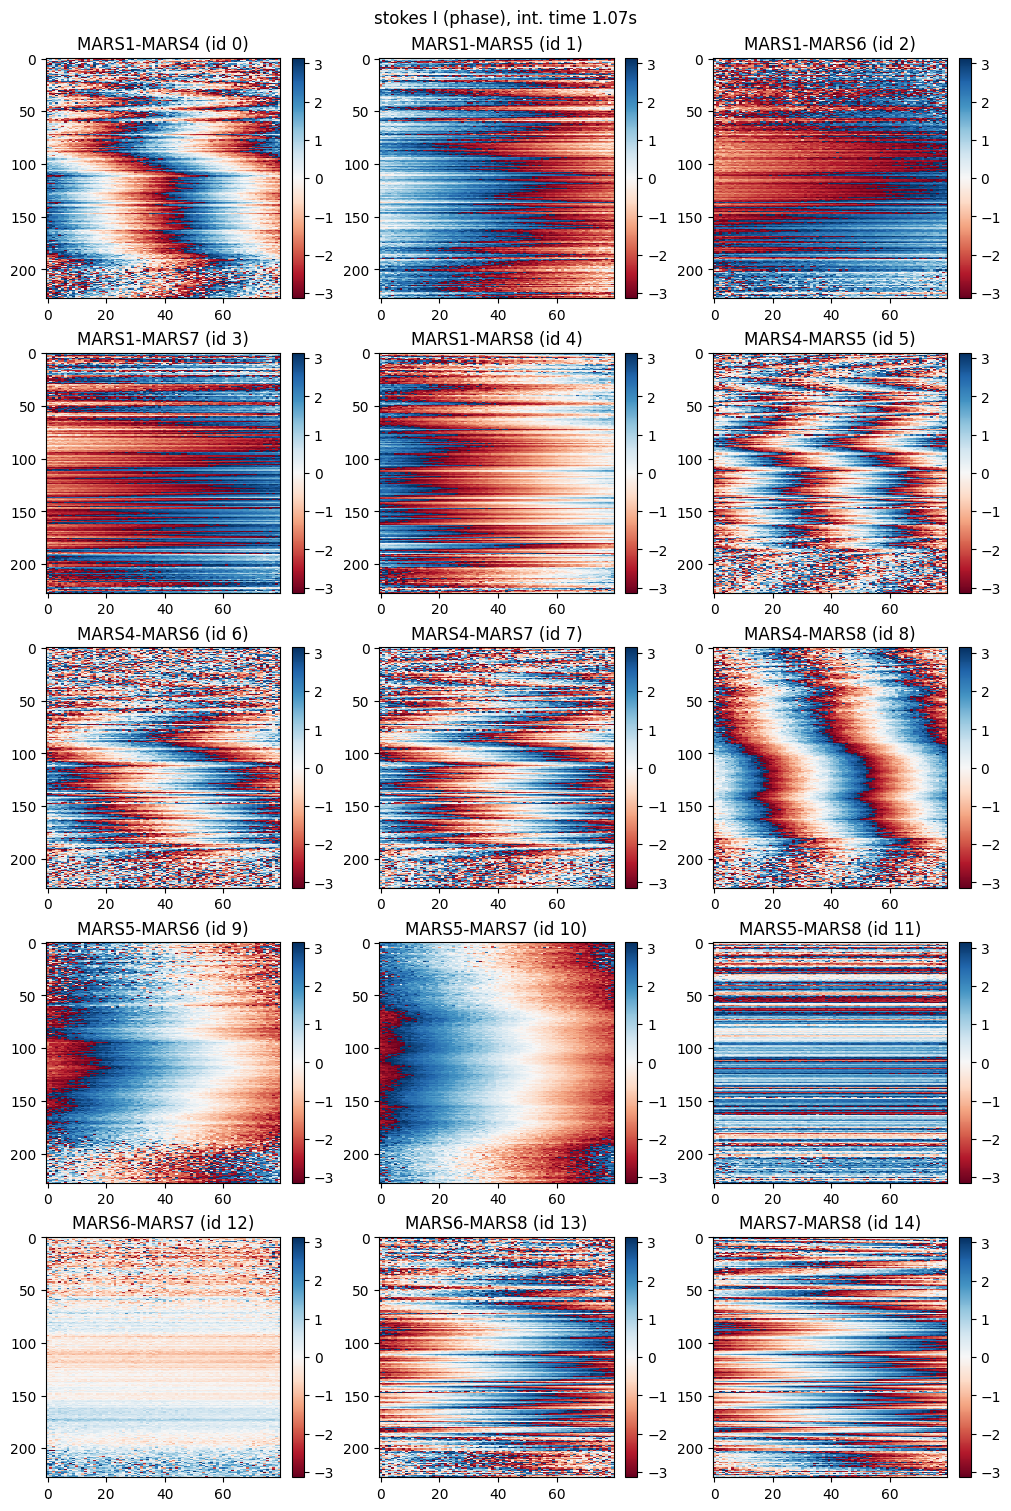

In [100]:
#generate phase plots for each baseline
nant=7
antmap = {0:"MARS1", 1:"MARS2",2:"MARS4",3:"MARS5",4:"MARS6",5:"MARS7",6:"MARS8"}
fig,ax = plt.subplots(5,3, constrained_layout=True)
fig.set_size_inches(10,15)
ax=np.ravel(ax)
pnum=0
print(n_blines)
plt.suptitle(f"stokes I (phase), int. time {T_SPECTRA*acclen:4.2f}s")
x = np.arange(data.shape[3])
thermal_noise = np.zeros((n_blines, multi_vis.shape[1]),dtype='float64')
vis_noise = np.zeros((n_blines, multi_vis.shape[1]),dtype='float64')
for i in range(len(ant_idxs)):
        for j in range(i+1, len(ant_idxs)):
            ai = ant_idxs[i]
            aj = ant_idxs[j]
            ax[pnum].set_title(f"{antmap[ai]}-{antmap[aj]} (id {pnum})")
            a=np.unwrap(np.angle(multi_vis[pnum,:,:]),axis=1)
            for k in range(a.shape[0]):
                m, c = np.polyfit(x, a[k,:], 1)
                residual = a[k,:] - (m*x + c)
                # sigma_phi = np.sqrt(np.mean(residual**2))
                sigma_phi = np.std(np.angle(np.exp(1j*residual)))
                thermal_noise[pnum,k] = sigma_phi
                vis_noise[pnum,k] = np.std(np.cos(residual))
            b=np.unwrap(a,axis=0)
            img=ax[pnum].imshow(np.angle(multi_vis[pnum,:,:]),aspect='auto',interpolation='none',cmap='RdBu')
            cbar=plt.colorbar(img,ax=ax[pnum])
            #ax[pnum].set_ylim(cut_start,cut_end)
            pnum+=1
# plt.tight_layout()

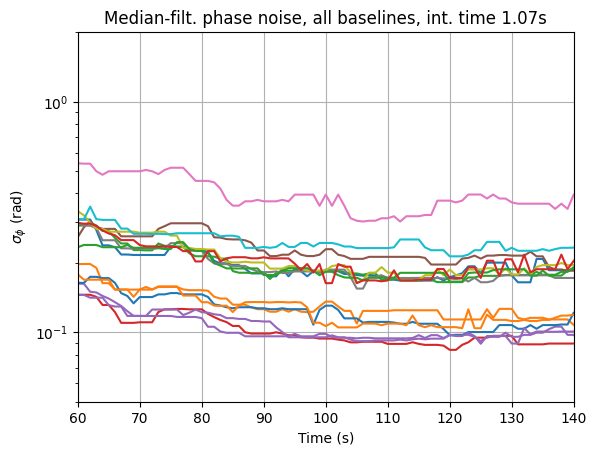

In [92]:
for bl in range(nbl):
    plt.semilogy(median_filter(thermal_noise[bl,:],10),label=f'bl id {bl}')
plt.title(f"Median-filt. phase noise, all baselines, int. time {T_SPECTRA*acclen:4.2f}s")
plt.ylabel("$\sigma_\phi$ (rad)")
plt.xlabel("Time (s)")
plt.xlim(cut_start,cut_end)
plt.ylim(0.05,2)
plt.grid(True)

In [95]:
@nb.njit()
def func(tau_t, data, freq, weights):
    # for one time sample
    nant=6
    nbl = nant*(nant-1)//2
    nfreq = len(freq)
    n_eval = nfreq * nbl
    residuals = np.zeros((2 * n_eval,), dtype="float64")
    for j in range(nfreq):
        blnum = 0
        two_pi_nu = 2 * np.pi * nu[j]
        for ai in range(nant):
            for aj in range(ai + 1, nant):
                rowidx = j * nbl + blnum
                w = weights[blnum]
                if ai == 0:
                    pred = (
                        -two_pi_nu * tau_t[aj - 1]
                    )  # ant 0 is refant
                else:
                    pred = (
                        two_pi_nu * (tau_t[ai - 1] - tau_t[aj - 1])
                    )
                y = np.exp(1j * pred) - np.exp(1j*data[rowidx])
                residuals[rowidx] = w * np.real(y)
                residuals[rowidx + n_eval] = w * np.imag(y)
                blnum += 1
    return residuals

@nb.njit()
def jac(tau_t, data, freq, weights):
    nant=6
    nbl = nant*(nant-1)//2
    nfreq = len(freq)
    n_eval = nfreq * nbl
    J = np.zeros((2 * n_eval, nant-1), dtype="float64")
    for j in range(nfreq):
        blnum = 0
        two_pi_nu = 2 * np.pi * nu[j]
        for ai in range(nant):
            for aj in range(ai + 1, nant):
                rowidx = j * nbl + blnum
                w = weights[blnum]
                if ai == 0:
                    pred = (
                        -two_pi_nu * tau_t[aj - 1]
                    )  # ant 0 is refant
                    ym = np.exp(1j * pred)
                    dtheta = 1j * ym * w
                    re = two_pi_nu * np.real(dtheta)
                    im = two_pi_nu * np.imag(dtheta)
                    J[rowidx, aj - 1] = -re
                    J[rowidx + n_eval, aj - 1] = -im
                else:
                    pred = (
                        two_pi_nu * (tau_t[ai - 1] - tau_t[aj - 1])
                    )
                    ym = np.exp(1j * pred)
                    dtheta = 1j * ym * w
                    re = two_pi_nu * np.real(dtheta)
                    im = two_pi_nu * np.imag(dtheta)
                    J[rowidx, ai - 1] = re
                    J[rowidx, aj - 1] = -re
                    J[rowidx + n_eval, ai - 1] = im
                    J[rowidx + n_eval, aj - 1] = -im
                blnum += 1
    return J

(15, 80)
(15, 80, 80)
(80, 80, 15) (80, 15) (80, 15)
nant,nfreq,ntime,nbl 6 80 80 15


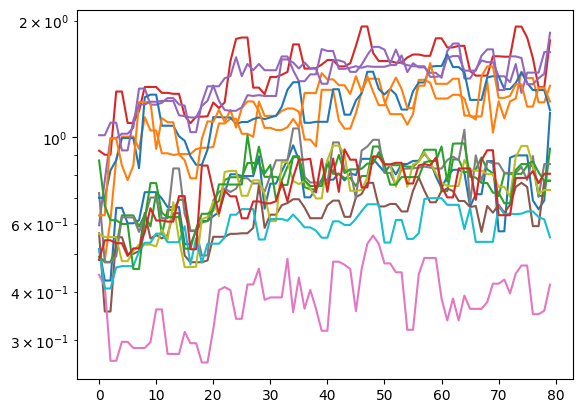

In [109]:
noise_var = median_filter(thermal_noise[:,cut_start:cut_end],3,axes=1)**2
print(noise_var.shape)
# noise_var = median_filter(vis_noise[:],2,axes=1)**2
# noise_var = thermal_noise[:]**2
weights = np.sqrt(np.size(noise_var)/noise_var/np.sum(1/noise_var))
for bl in range(nbl):
    plt.semilogy(weights[bl,:],label=f'bl id {bl}')
# plt.legend()
phase = np.angle(multi_vis[:, cut_start:cut_end, :])
phase = np.unwrap(phase,axis=2)
phase = np.unwrap(phase,axis=1)
print(phase.shape)

#make baseline fastest moving axis for convenience
data_matrix = phase.transpose(1,2,0).copy()
noise_matrix = noise_var.T.copy()
weight_matrix = weights.T.copy()
print(data_matrix.shape, weight_matrix.shape, noise_matrix.shape)


nu=freqs[chanids].copy()/1e9
nfreq=len(nu)
assert nfreq == data_matrix.shape[1]
ntime = data_matrix.shape[0]
nant = len(ant_to_use)

print("nant,nfreq,ntime,nbl", nant,nfreq,ntime,nbl)

done tt=0, time = 0.012
done tt=1, time = 0.012
done tt=2, time = 0.013
done tt=3, time = 0.012
done tt=4, time = 0.012
done tt=5, time = 0.012
done tt=6, time = 0.010
done tt=7, time = 0.011
done tt=8, time = 0.015
done tt=9, time = 0.011
done tt=10, time = 0.010
done tt=11, time = 0.010
done tt=12, time = 0.006
done tt=13, time = 0.006
done tt=14, time = 0.009
done tt=15, time = 0.006
done tt=16, time = 0.006
done tt=17, time = 0.006
done tt=18, time = 0.007
done tt=19, time = 0.014
done tt=20, time = 0.012
done tt=21, time = 0.006
done tt=22, time = 0.005
done tt=23, time = 0.010
done tt=24, time = 0.010
done tt=25, time = 0.008
done tt=26, time = 0.009
done tt=27, time = 0.009
done tt=28, time = 0.009
done tt=29, time = 0.006
done tt=30, time = 0.007
done tt=31, time = 0.009
done tt=32, time = 0.014
done tt=33, time = 0.013
done tt=34, time = 0.009
done tt=35, time = 0.010
done tt=36, time = 0.015
done tt=37, time = 0.016
done tt=38, time = 0.015
done tt=39, time = 0.016
done tt=40

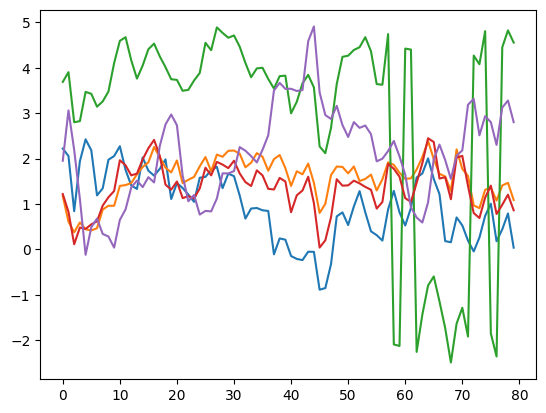

In [111]:
fit_taus = np.zeros((ntime,nant-1),dtype='float64')
x0=np.ones(nant-1)
for tt in range(ntime):
    ydata = data_matrix[tt,:,:].ravel()
    weights = weight_matrix[tt,:]
    t1=time.time()
    fit_params = least_squares(func, x0, args=(ydata,nu,weights),jac=jac,method='lm',ftol=1e-06, xtol=1e-06, gtol=1e-06, loss='linear')
    t2=time.time()
    fit_taus[tt,:]=fit_params['x']
    # print(fit_params)
    print(f"done tt={tt}, time = {t2-t1:5.3f}")
    
plt.plot(fit_taus)

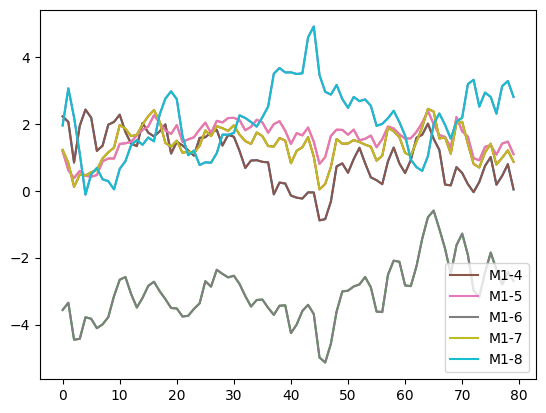

In [112]:
est_delay = np.unwrap(np.angle(np.exp(1j*fit_taus.reshape(-1,nant-1)*2*np.pi*nu.mean())),axis=0)/(2*np.pi*nu.mean())
plt.plot(est_delay[:,:])

labels=['M1-4', 'M1-5', 'M1-6', 'M1-7', 'M1-8']
est_delay = np.unwrap(np.angle(np.exp(1j*fit_taus.reshape(-1,nant-1)*2*np.pi*nu.mean())),axis=0)/(2*np.pi*nu.mean())
plt.plot(est_delay[:,:],label=labels)
plt.legend()

In [ ]:
#generate phase plots for each baseline
antmap = {0:"MARS1", 1:"MARS2",2:"MARS4",3:"MARS5",4:"MARS6",5:"MARS7",6:"MARS8"}
fig,ax = plt.subplots(5,3, constrained_layout=True)
fig.set_size_inches(10,15)
ax=np.ravel(ax)
pnum=0
print(nbl)
plt.suptitle(f"stokes I (phase), int. time {T_SPECTRA*acclen:4.2f}s")
x = np.arange(len(chanids))
phased_vis = np.empty_like(multi_vis[:,:cut,:])
for i in range(len(ant_to_use)):
        for j in range(i+1, len(ant_to_use)):
            ai = ant_to_use[i]
            aj = ant_to_use[j]
            if i==0:
                tau1=0
            else:
                tau1=est_delay[:,i-1]
            tau2 = est_delay[:,j-1]
            rel_delay = tau1-tau2
            ax[pnum].set_title(f"{antmap[ai]}-{antmap[aj]} (id {pnum})")
            phased_vis[pnum,:,:]=multi_vis[pnum,:cut,:]*np.exp(-2j*np.pi*nu[None,:]*rel_delay[:,None])
            img=ax[pnum].imshow(np.angle(phased_vis[pnum,:,:]),aspect='auto',interpolation='none',cmap='RdBu')
            cbar=plt.colorbar(img,ax=ax[pnum])
            pnum+=1
# plt.tight_layout()

In [ ]:

avg_multi_vis = np.mean(phased_vis,axis=1)
# avg_multi_vis = np.median(phased_vis,axis=1)
avg_multi_vis = avg_multi_vis.T.copy()
plt.plot(np.unwrap(np.angle(avg_multi_vis),axis=0))
print(avg_multi_vis.shape)
noise_matrix_avg = np.zeros((1,nbl),dtype='float64')
for bl in range(nbl):
    y = np.unwrap(np.angle(avg_multi_vis[:,bl]))
    m, c = np.polyfit(x,y, 1)
    residual = y - (m*x + c)
    noise_matrix_avg[0,bl] = np.std(residual)
print(noise_matrix_avg)

In [ ]:

ntime2=1
nant=6
nbl=nant*(nant-1)//2
data_matrix = np.unwrap(np.angle(avg_multi_vis),axis=0)
data_matrix = data_matrix.reshape(ntime2,nfreq,nbl)
Ag = timing.get_grammian(nant)
print(data_matrix.shape)
AtA2,Atd2 = timing.get_AtA_Atd(data_matrix,Ag,noise_matrix_avg**2,nu,nant,nfreq,ntime2,fit_constant=True)
AtA_inv2 = np.linalg.inv(AtA2)

mfit2 = AtA_inv2 @ Atd2

# Total parameters for tau: ntime * (nant-1)
bs = nant - 1
tau_linear2 = mfit2[:ntime2 * bs]
phi_linear2 = mfit2[ntime2 * bs:]
print(np.sqrt(np.diag(AtA_inv2)))
print(tau_linear2)